01_inventario
02_frescura cero  de la base de abril join abril y marzo  
03_cliente con la base regular  
04_base regular  lo que queda

In [ ]:
punto de equilibrio


In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

### armar lista credicash

In [2]:

query = """
  SELECT * FROM cronox.dbo.borrar_credicash
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

# df_list = df_list.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list = df_list.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list = df_list.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list.columns)
print(df_list.count())

['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash'

In [3]:
df_list=df_list.withColumn('lote_01',F.when(F.col('lote')=='REINGRESO',F.lit('05. REINGRESO'))
    .when(F.col('frescura')=='0','02. FRESCURA CERO')
    .when(F.col('grupo_segmento')=='R',F.lit('03.BASE CLIENTE'))
    .when(F.col('lote')=='INVENTARIO','01.INVENTARIO')
    .otherwise(F.lit('04.BASE REGULAR'))
)

In [4]:
df_list.dropDuplicates(['dni_cliente']).groupBy('lote_01') \
    .count() \
    .orderBy('lote_01') \
    .show(30, truncate=False)

+-----------------+------+
|lote_01          |count |
+-----------------+------+
|01.INVENTARIO    |190089|
|02. FRESCURA CERO|33186 |
|03.BASE CLIENTE  |14499 |
|04.BASE REGULAR  |21024 |
|05. REINGRESO    |6     |
+-----------------+------+



In [18]:
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print([row['propension_credicash' ] for row in df_list.select('propension_credicash').distinct().collect()])



['DERIVA A CASILLA DE VOZ', 'TELÉFONO APAGADO', 'CORTA LLAMADA', 'EXPRESO RECIBIR MÚLTIPLES LLAMADAS', 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA', 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO', 'CITA AGENDADA', 'EXPRESO FUTURA DENUNCIA ANTE INDECOPI O REGULADOR', 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO', 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES', 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD', 'NO CONOCE ALFIN BANCO', 'NO BRINDARÁ INFORMACIÓN A TITULAR', 'BRINDARÁ INFORMACIÓN A TITULAR', 'ALFIN NO TIENE SUCURSAL CERCA', 'CLIENTE ACEPTA OFERTA Y PASARÁ A PROCESO DE DESEMBOLSO', 'DISCADOR', 'FUERA DE SERVICIO', 'CLIENTE CONFIRMA QUE YA DESEMBOLSÓ', 'NO CONTESTAN', 'SOLICITÓ NO SER CONTACTADO', 'EXPRESO QUE NO AUTORIZÓ USO DE DATOS PERSONALES', None]


In [5]:
mejor_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR']
# semaforo=['04 EN RECUPERACIÓN', '03 NORMAL', '05 ESPECIAL', '02 FLEXIBLE', ]

propension_electro=['1','2' ]
propension_credicash=['1','2']
# propension_ic=['3', '5', '6', '1', '4', '2']
frescura=['0', '1','3']
# frescura=['3', '0', '1', '4', '2', None]
# region_comercial=['REGION SUR', 'REGION LIMA CENTRO', 'REGION LIMA SUR ORIENTE', 'REGION CENTRO ORIENTE', 'REGION LIMA NORTE', 'REGION NORTE', 'REGION LIMA SUR', 'REGION LIMA', ]
region_comercial=['REGION SUR', 'REGION LIMA CENTRO', 'REGION LIMA SUR ORIENTE', '', 'REGION LIMA NORTE', 'REGION NORTE', '', '', ]

agencia_comercial=['LOS OLIVOS', 'VILLA MARIA 2', 'MOSHOQUEQUE', 'PUENTE PIEDRA', 'COMAS', 'PUCALLPA', 'PISCO', 'TARAPOTO', 'CHINCHA', 'VENTANILLA', 'VILLA EL SALVADOR 2', 'PC TACNA', 'CAÑETE', 'HUANUCO', 'SANTA ANITA', 'JESUS MARIA', 'EMANCIPACION', 'CAJAMARCA', 'SAN MARTIN', 'SAN MIGUEL', 'MIRAFLORES', 'AREQUIPA CAYMA', 'CAÃ‘ETE', 'SULLANA', 'AREQUIPA PAMPILLA', 'IQUITOS', 'ATE VITARTE', 'CHICLAYO BALTA', 'HUACHO', 'SAN JUAN DE MIRAFLORES', 'SAN JUAN DE LURIGANCHO', 'PC HUARAZ', 'PC HUANCAYO', 'ICA', 'CASTILLA', 'TRUJILLO CENTRO', 'CHIMBOTE', 'JULIACA 2', 'HUARAL', 'TRUJILLO AMERICA', 'CUSCO LA CULTURA', ]
# producto_externo=['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']

mejor15_descripcion_telf=[
    'DERIVA A CASILLA DE VOZ',
 'TELÉFONO APAGADO',
 'CORTA LLAMADA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'DISCADOR',
 'NO CONTESTAN',
 ]

retiro=['no aplica',]
tipo_telf=['cel01']
# propension_electro=[1, 3, 5, 4, 2]
# propension_credicash=[1, 3, 5, 4, 2]
propension_credicash=[1, 2]
propension_electro=[1, 2]


# producto_externo=['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']
perfil=[  'D0']
# perfil=['O1', 'D1', 'O2', 'O3', 'D2', 'D0']
semaforo=[ '02 FLEXIBLE', ]
region=['R4', 'R5', 'R1']
# region=['R6', 'R3', 'R2', 'R7', 'R4', 'R5', 'R1', None]

In [6]:
retiro=['no aplica',]


In [7]:
# mejor15_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', 'NO ', 'DISCADOR', 'CONTACTO CON TERCERO', None]
mejor15_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', 'NO ', '', 'CONTACTO  ', ]


In [22]:
mejor15_descripcion_telf=[
 'TELÉFONO APAGADO',
 'CORTA LLAMADA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'DISCADOR',
 'NO CONTESTAN',
 ]



In [9]:
producto_externo=['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']


In [26]:
df_list_filtrada = df_parte_1.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_1.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [27]:
df_list_filtrada = df_parte_2.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_2.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [28]:
df_list_filtrada = df_parte_3.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_3.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [14]:
df_list_filtrada = df_parte_4.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_4.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [17]:
df_list_filtrada = df_parte_6.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_6.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [18]:
df_list_filtrada = df_parte_7.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_7.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [12]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

+-----------------------+-----+
|producto_externo       |count|
+-----------------------+-----+
|CREDICASH              |878  |
|CREDICASH / ELECTRO    |21896|
|CREDICASH / ELECTRO MSI|26003|
+-----------------------+-----+



In [24]:

df_filtrado = df_list.filter(
    ((F.col('mejor15_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    (F.col('retiro').isin(retiro))&    
    (
        (F.col('producto_externo').isin('CREDICASH R','CREDICASH R / ELECTRO',))|
        ((F.col('frescura').isin('0'))&(F.col('producto_externo').isin('CREDICASH')))
    ) &    
    ((F.col('fecha_llamada').isNull())|(F.col('fecha_llamada')<'2026-04-23'))


).orderBy(F.col('oferta_max').desc())

print(df_filtrado.count())
print(df_filtrado.columns)

15265
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_cred

In [ ]:
producto_externo=['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']


In [9]:
lote_01=['04.BR', '02. FRESCURA CERO', '03.BANTE', '01.INVENTARIO', '05.']
# lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']


In [21]:
df_parte_1.count()

7355

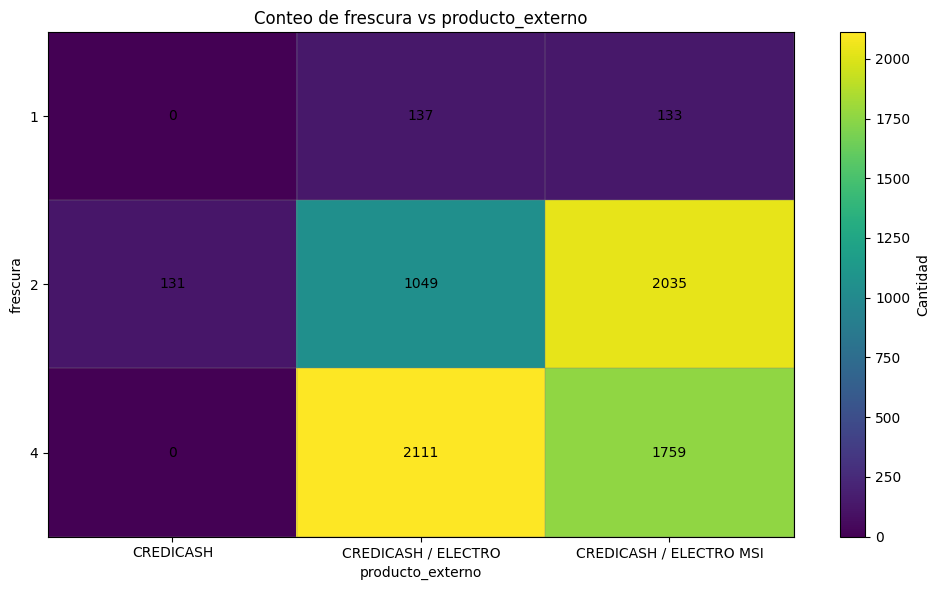

In [20]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_plot = (
    df_parte_1.groupBy("frescura", "producto_externo")
    .count()
)

pdf = df_plot.toPandas()

pdf["producto_externo"] = pdf["producto_externo"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)

tabla = pdf.pivot(index="frescura", columns="producto_externo", values="count").fillna(0)
tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

# im = ax.imshow(tabla.values, aspect="auto")
# im = ax.imshow(tabla.values, aspect="auto", cmap="YlGnBu")
im = ax.imshow(tabla.values, aspect="auto")
# im = ax.imshow(tabla.values, aspect="auto", cmap="YlOrRd")
# im = ax.imshow(
#     tabla.values,
#     aspect="auto",
#     cmap="YlGnBu",
#     vmin=0,
#     vmax=np.percentile(tabla.values, 90)   # 👈 clave
# )
# )
ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title("Conteo de frescura vs producto_externo")
ax.set_xlabel("producto_externo")
ax.set_ylabel("frescura")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)
ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# mostrar etiquetas dentro de cada celda
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, int(tabla.iloc[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

+-----------------------+-----+
|producto_externo       |count|
+-----------------------+-----+
|CREDICASH              |878  |
|CREDICASH / ELECTRO    |21896|
|CREDICASH / ELECTRO MSI|26003|
+-----------------------+-----+



In [27]:
df_filtrado.groupBy('lote_01') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------------+-----+
|lote_01      |count|
+-------------+-----+
|01.INVENTARIO|51401|
+-------------+-----+



In [21]:
df_filtrado.groupBy('mejor15_descripcion_cli') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------------------------------------------------+-----+
|mejor15_descripcion_cli                          |count|
+-------------------------------------------------+-----+
|DISCADOR                                         |16601|
|NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO       |2110 |
|CORTA LLAMADA                                    |1927 |
|BRINDARÁ INFORMACIÓN A TITULAR                   |447  |
|DERIVA A CASILLA DE VOZ                          |299  |
|NO BRINDARÁ INFORMACIÓN A TITULAR                |267  |
|NO CONTESTAN                                     |248  |
|NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES|156  |
|YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD            |107  |
|NULL                                             |97   |
|TELÉFONO APAGADO                                 |92   |
|ALFIN NO TIENE SUCURSAL CERCA                    |16   |
|NO CONOCE ALFIN BANCO                            |1    |
+-------------------------------------------------+-----+



In [29]:
df_split = df_split.cache()
df_split.count() 

Py4JJavaError: An error occurred while calling o691.count.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 109.0 failed 1 times, most recent failure: Lost task 0.0 in stage 109.0 (TID 62) (DESKTOP-47B8JAC executor driver): com.microsoft.sqlserver.jdbc.SQLServerException: Connection reset
	at com.microsoft.sqlserver.jdbc.SQLServerConnection.terminate(SQLServerConnection.java:4708)
	at com.microsoft.sqlserver.jdbc.TDSChannel.read(IOBuffer.java:2195)
	at com.microsoft.sqlserver.jdbc.TDSReader.readPacket(IOBuffer.java:6975)
	at com.microsoft.sqlserver.jdbc.TDSReader.nextPacket(IOBuffer.java:6923)
	at com.microsoft.sqlserver.jdbc.TDSReader.ensurePayload(IOBuffer.java:6895)
	at com.microsoft.sqlserver.jdbc.TDSReader.readBytes(IOBuffer.java:7218)
	at com.microsoft.sqlserver.jdbc.TDSReader.readWrappedBytes(IOBuffer.java:7263)
	at com.microsoft.sqlserver.jdbc.TDSReader.readInt(IOBuffer.java:7188)
	at com.microsoft.sqlserver.jdbc.TDSReader.readUnsign

In [25]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('producto_externo',"frescura",'propension_credicash').orderBy(F.rand())

df_split = df_filtrado.withColumn("grupo_split", F.ntile(3).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")
# df_parte_5 = df_split.filter(F.col("grupo_split") == 5).drop("grupo_split")
# df_parte_6 = df_split.filter(F.col("grupo_split") == 6).drop("grupo_split")
# df_parte_7 = df_split.filter(F.col("grupo_split") == 7).drop("grupo_split")

print(
    df_parte_1.count(),
    df_parte_2.count(),
    df_parte_3.count()
    # df_parte_4.count(),
    # df_parte_5.count(),
    # df_parte_6.count(),
    # df_parte_7.count()
)

5109 5086 5070


In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutvo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro']prope
v

In [19]:
from pyspark.sql.window import Window

window_agencia = Window.partitionBy('region',"tienda_ir")

df_final = df_filtrado.withColumn(
    "cnt_agencia",
    F.count("*").over(window_agencia)
)
df_final=df_final.filter(
    F.col("cnt_agencia") > 100
)
print(df_final.count())


4122


In [21]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfcc_202604211__2.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [15]:
producto_externo=[
 'CREDICASH',
 'CREDICASH R / ELECTRO',
 ]
# producto_externo=['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']


['CREDICASH']

In [20]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga',
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'cregfhxxx__1.csv')

import csv

df_list_filtrada.to_csv(
    ruta_archivo,
    index=False,
    sep=",",
    header=False,
    encoding="latin-1", 
    lineterminator="\r\n"
)


df_list_filtrada.count()

cabecera_carga    7873
dtype: int64

In [ ]:
df_filtrado.groupBy('lote_01') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

{"ts": "2026-04-23 17:52:17.959", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[CAST_INVALID_INPUT] The value 'INVENTARIO' of the type \"STRING\" cannot be cast to \"BIGINT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018", "context": {"file": "line 4 in cell [10]", "line": "", "fragment": "__eq__", "errorClass": "CAST_INVALID_INPUT"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o767.showString.\n: org.apache.spark.SparkNumberFormatException: [CAST_INVALID_INPUT] The value 'INVENTARIO' of the type \"STRING\" cannot be cast to \"BIGINT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018\n== DataFrame ==\n\"__eq__\" was called from\nline 4 in cell [10]\n\r\n\tat org.apache.spark.sql.err

NumberFormatException: [CAST_INVALID_INPUT] The value 'INVENTARIO' of the type "STRING" cannot be cast to "BIGINT" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"__eq__" was called from
line 4 in cell [10]


In [ ]:
producto_externo=[
    'CREDICASH R / ELECTRO MSI',
 'CREDICASH R / ELECTRO',
 'CREDICASH',
 ]



In [15]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-----------------------+-----+
|producto_externo       |count|
+-----------------------+-----+
|CREDICASH / ELECTRO    |5077 |
|CREDICASH / ELECTRO MSI|3908 |
|CREDICASH              |889  |
+-----------------------+-----+



In [40]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

+-------------------------+-----+
|producto_externo         |count|
+-------------------------+-----+
|CREDICASH / ELECTRO      |5416 |
|CREDICASH / ELECTRO MSI  |2079 |
|CREDICASH R / ELECTRO    |156  |
|CREDICASH R / ELECTRO MSI|27   |
+-------------------------+-----+



In [ ]:
producto_externo=[
    'CREDICASH R / ELECTRO MSI',
 'CREDICASH R / ELECTRO',
 'CREDICASH R',
 'CREDICASH / ELECTRO',
 'CREDICASH',
 ]


In [ ]:

df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'credicash_.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [119]:
print([row['mejor15_descripcion_telf' ] for row in df_list_cencosud.select('mejor15_descripcion_telf').distinct().collect()])


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'AUTODIAL NO RESPONDE (AUTO)', 'OCUPADO (AUTO)', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'AGENTE NO DISPONIBLE (AUTO)']


In [ ]:

exportar_lista(df_filtrado,'tc_cenco_2026033014.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]
